# Dijkstra Benchmark Analysis
Comparação de desempenho entre **PairingHeap**, **BinaryHeap** e **FibonacciHeap**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ─── Carregar dados ───────────────────────────────────────────────────────────
df = pd.read_csv("../experiments/results/dijkstra_results.csv")
df.columns = df.columns.str.strip().str.replace('"', '')

# Renomear coluna com vírgula no nome
df.rename(columns={"Score Error (99,9%)": "Score Error (99.9%)"}, inplace=True)

# Corrigir separador decimal com vírgula
df["Score"] = df["Score"].astype(str).str.replace(",", ".").astype(float)
df["Score Error (99.9%)"] = df["Score Error (99.9%)"].astype(str).str.replace(",", ".").astype(float)

# Agregar duplicatas tirando a média
df = df.groupby(
    ["Benchmark", "Param: graphType", "Param: heapType", "Param: size"],
    as_index=False
).agg({"Score": "mean", "Score Error (99.9%)": "mean"})

# Configurações compartilhadas
heaps       = ["PAIRING", "BINARY", "FIBONACCI"]
palette     = {"PAIRING": "#E05C5C", "BINARY": "#4A90D9", "FIBONACCI": "#4CAF50"}
graph_types = sorted(df["Param: graphType"].dropna().unique())
sizes       = sorted(df["Param: size"].dropna().unique().astype(int))
x           = np.arange(len(sizes))
n_heaps     = len(heaps)
width       = 0.25

def plot_metric(benchmark_name, label, filename_prefix):
    """Gera um gráfico por tipo de grafo (densidade) para a métrica informada."""
    for graph_type in graph_types:
        subset = df[
            (df["Benchmark"] == benchmark_name) &
            (df["Param: graphType"] == graph_type)
        ].copy()
        subset["Param: size"] = subset["Param: size"].astype(int)

        fig, ax = plt.subplots(figsize=(9, 5))
        fig.suptitle(
            f"Dijkstra Benchmark — {label} ({graph_type})",
            fontsize=13, fontweight="bold"
        )

        for i, heap in enumerate(heaps):
            vals, errs = [], []
            for s in sizes:
                row = subset[
                    (subset["Param: heapType"] == heap) &
                    (subset["Param: size"] == s)
                ]
                vals.append(float(row["Score"].values[0]) if len(row) else 0)
                err_val = row["Score Error (99.9%)"].values[0] if len(row) else 0
                try:
                    parsed = float(err_val)
                    errs.append(0 if np.isnan(parsed) else parsed)
                except (ValueError, TypeError):
                    errs.append(0)

            offset = (i - (n_heaps - 1) / 2) * width
            bars = ax.bar(x + offset, vals, width, label=heap, color=palette[heap], alpha=0.88)
            ax.errorbar(x + offset, vals, yerr=errs, fmt='none', color='black', capsize=4, linewidth=1.2)

            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                        f"{v:.3g}", ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels([f"{s} vértices" for s in sizes])
        ax.set_ylabel(label, fontsize=10)
        ax.legend(fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(
            lambda v, _: f"{v:,.0f}" if v >= 1000 else f"{v:.3g}"))
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        filename = f"{filename_prefix}_{graph_type.lower()}.png"
        plt.savefig(filename, dpi=150, bbox_inches="tight")
        print(f"Gráfico salvo em {filename}")
        plt.show()

print(f"Setup concluído! Tipos de grafo encontrados: {graph_types}")

Setup concluído! Tipos de grafo encontrados: ['DENSE', 'MEDIUM', 'SPARSE']


## 1. Tempo de execução (ms/op)

Gráfico salvo em chart_tempo.png_dense.png


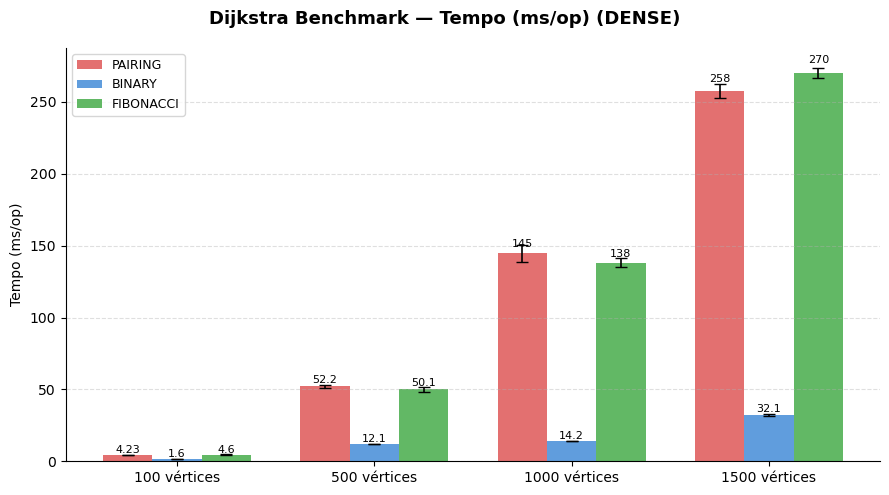

Gráfico salvo em chart_tempo.png_medium.png


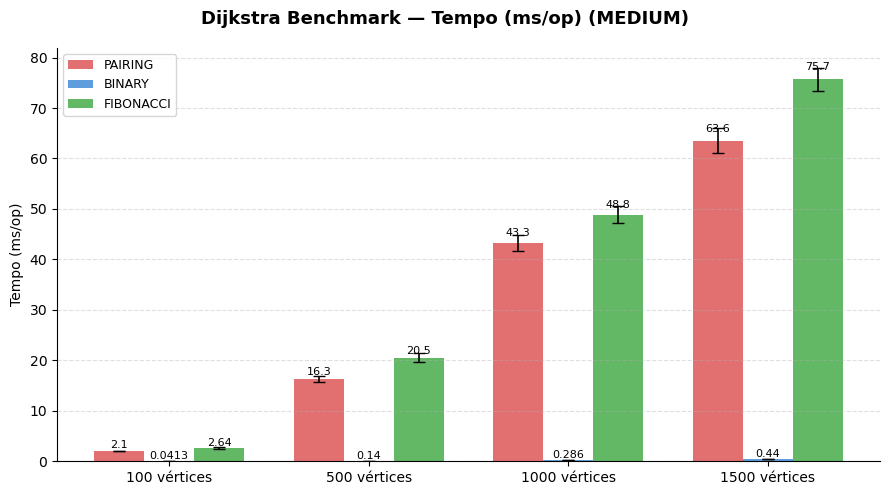

Gráfico salvo em chart_tempo.png_sparse.png


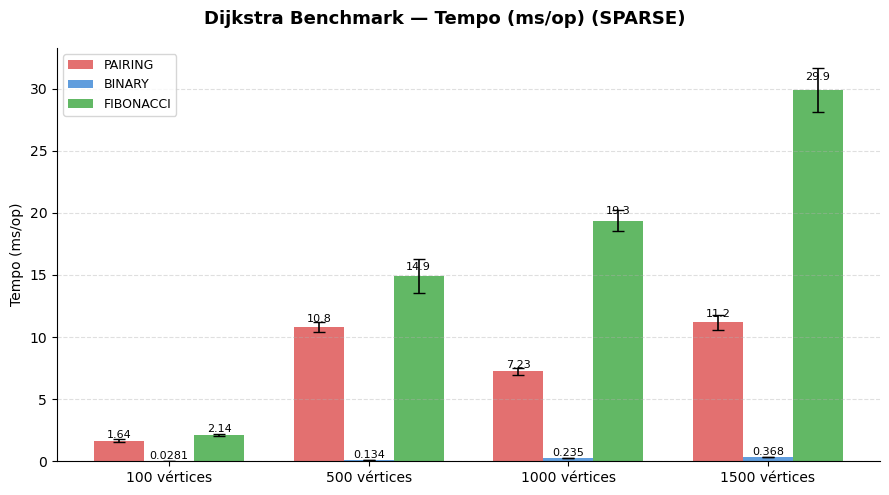

In [2]:
plot_metric(
    "benchmarks.DijkstraBenchmark.runDijkstra",
    "Tempo (ms/op)",
    "chart_tempo.png"
)

## 2. Alocação de memória por operação (B/op)

Gráfico salvo em chart_alocacao.png_dense.png


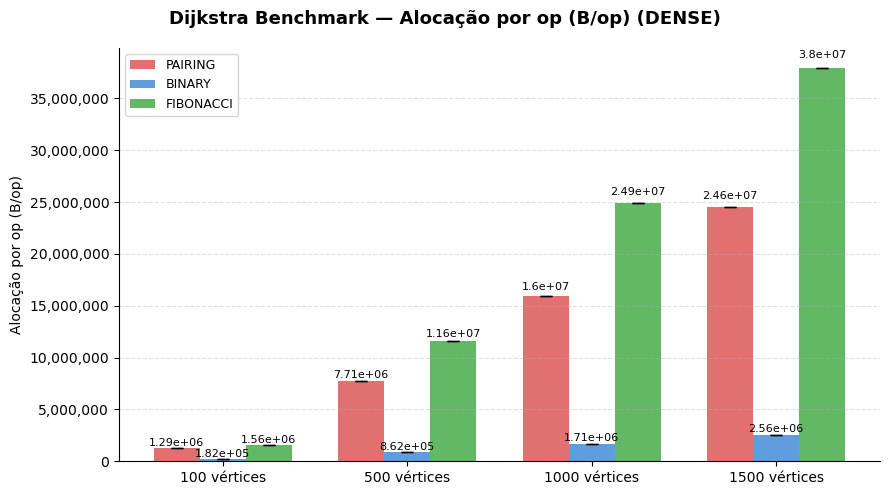

Gráfico salvo em chart_alocacao.png_medium.png


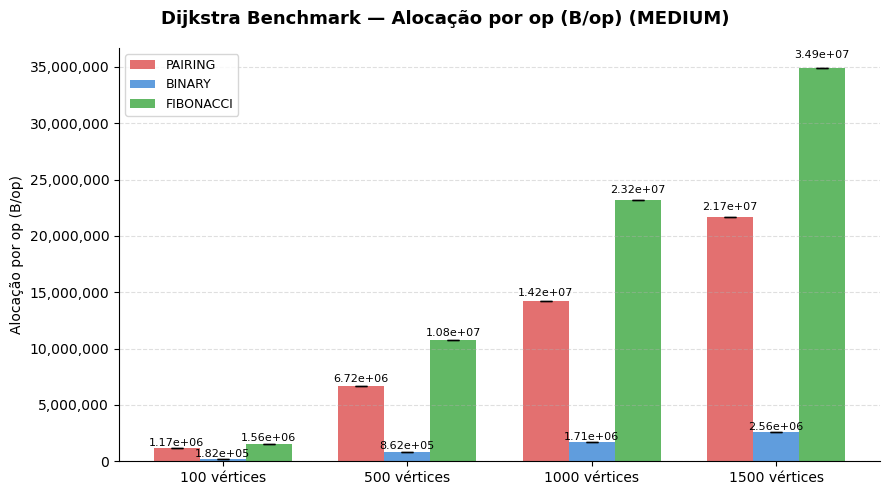

Gráfico salvo em chart_alocacao.png_sparse.png


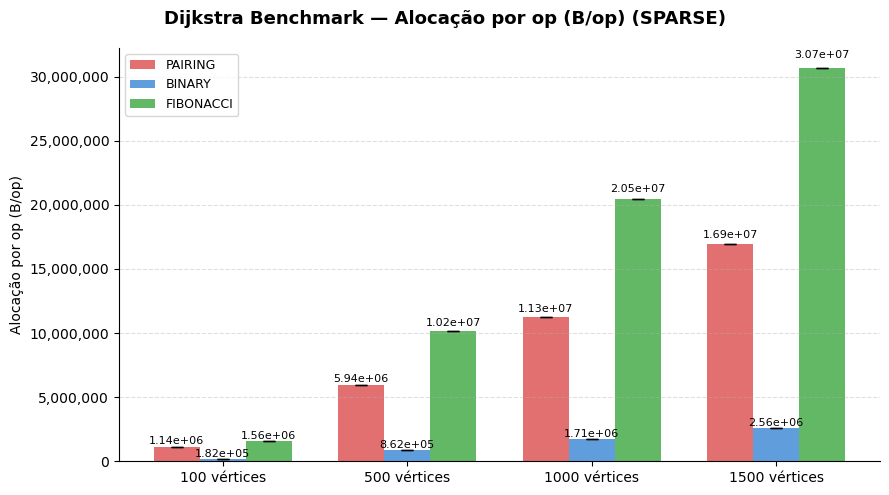

In [3]:
plot_metric(
    "benchmarks.DijkstraBenchmark.runDijkstra:gc.alloc.rate.norm",
    "Alocação por op (B/op)",
    "chart_alocacao.png"
)

## 3. Coletas de Garbage Collection (count)

Gráfico salvo em chart_gc_count.png_dense.png


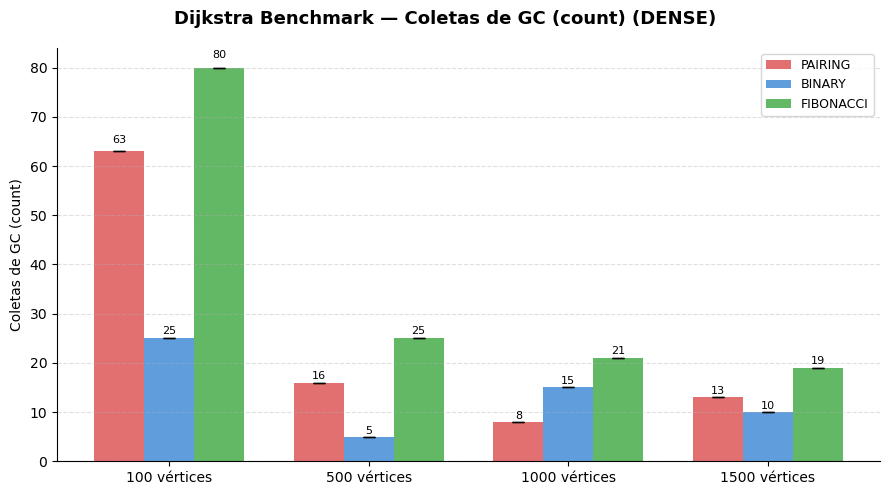

Gráfico salvo em chart_gc_count.png_medium.png


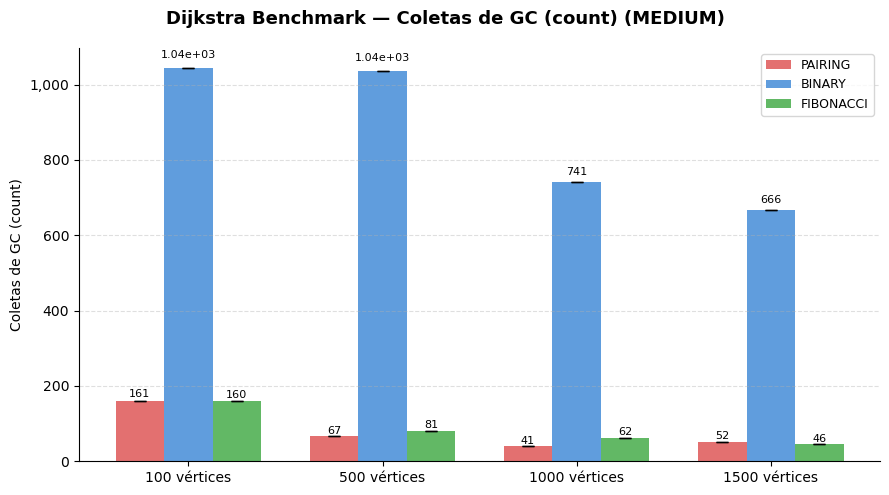

Gráfico salvo em chart_gc_count.png_sparse.png


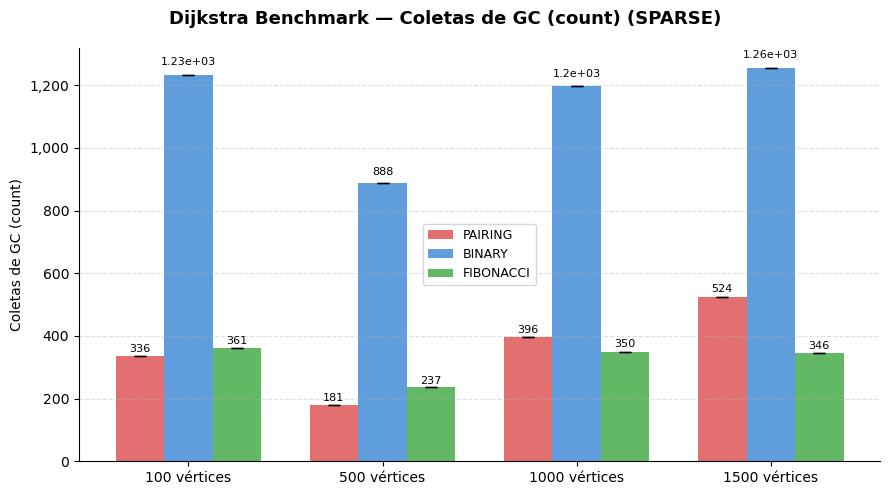

In [4]:
plot_metric(
    "benchmarks.DijkstraBenchmark.runDijkstra:gc.count",
    "Coletas de GC (count)",
    "chart_gc_count.png"
)

## 4. Tempo Gasto em Garbage Collection (ms)

Gráfico salvo em chart_gc_time.png_dense.png


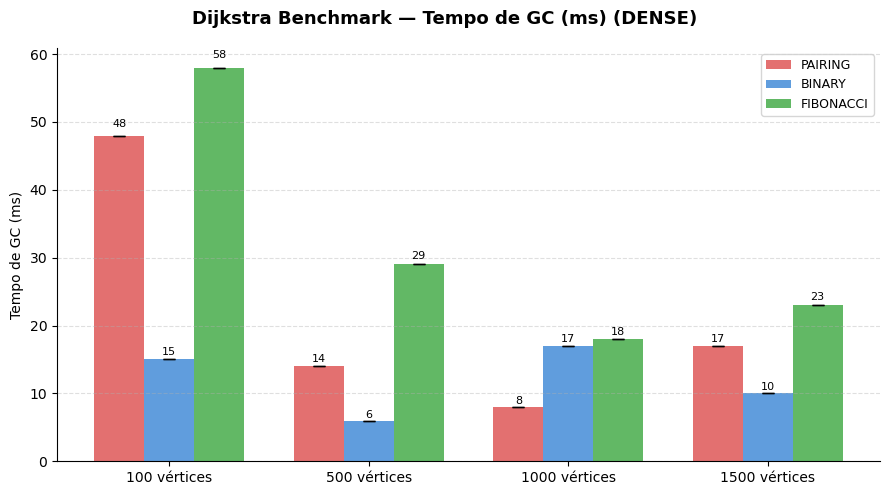

Gráfico salvo em chart_gc_time.png_medium.png


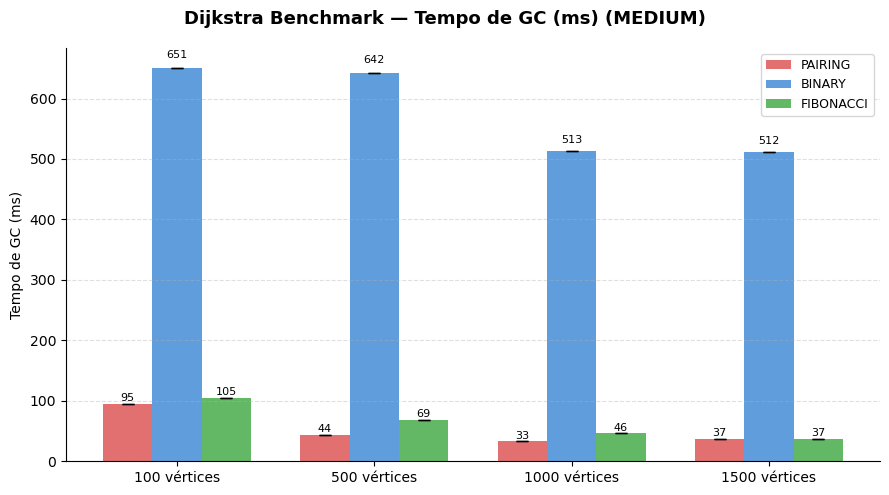

Gráfico salvo em chart_gc_time.png_sparse.png


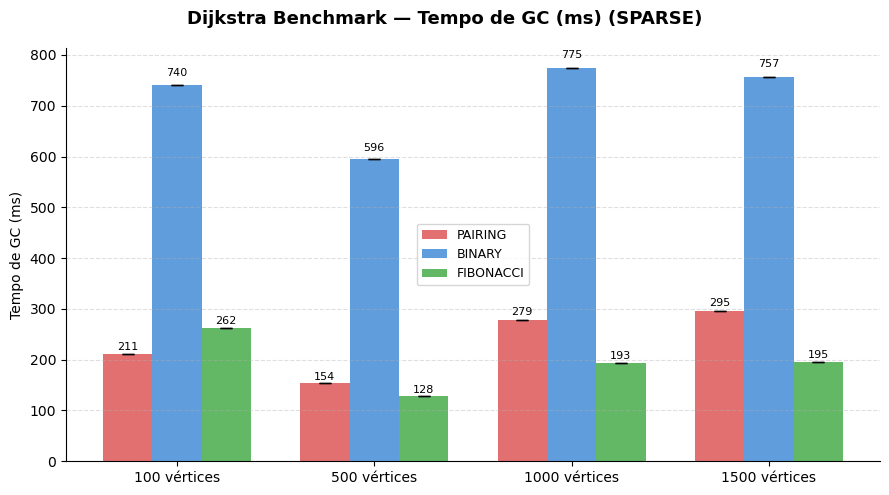

In [5]:
plot_metric(
    "benchmarks.DijkstraBenchmark.runDijkstra:gc.time",
    "Tempo de GC (ms)",
    "chart_gc_time.png"
)